<a href="https://colab.research.google.com/github/awinarko-hue/Latihan/blob/main/CompVis/Unet_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# U-Net Image Segmentation & Architecture Explanation

This notebook provides a complete walk-through of the famous **U-Net** architecture for semantic image segmentation. We will construct a U-Net from scratch in PyTorch, train it on a synthetic "biological cell" segmentation task, visualize the output, and finally **upload our own custom images** to test the model's predictions.

---

## How U-Net Works

U-Net was introduced by Olaf Ronneberger et al. in 2015 for biomedical image segmentation. It gets its name from its symmetrical, U-shaped layout:

```text
Contracting Path (Encoder)                      Expansive Path (Decoder)
========================================================================
Input Image (128x128)                                  Output (128x128)
   │                                                          ▲
   ▼                                                          │
[DoubleConv 16] ───►───► [Skip Connection] ───►───► [DoubleConv 16 + Concat]
   │ MaxPool                                            ▲ UpConv
   ▼                                                    │
[DoubleConv 32] ───►───► [Skip Connection] ───►───► [DoubleConv 32 + Concat]
   │ MaxPool                                            ▲ UpConv
   ▼                                                    │
[DoubleConv 64] ───►───► [Skip Connection] ───►───► [DoubleConv 64 + Concat]
   │ MaxPool                                            ▲ UpConv
   ▼                                                    │
   └───────────────► [Bottleneck 128] ──────────────────┘
```

### Symmetrical Blocks of the U-Net:

1. **Contracting Path (Encoder)**:
   - Extracts high-level feature maps while reducing spatial dimension (downsampling).
   - Consists of repeated blocks of **Double 3x3 Convolutions** followed by a **2x2 Max Pooling** layer.
   - Doubles the number of feature channels at each downsampling step.

2. **Bottleneck**:
   - The base layer of the "U". It extracts highly dense semantic features from the lowest-resolution spatial representation of the image.

3. **Expansive Path (Decoder)**:
   - Restores the spatial dimensions of the features (upsampling).
   - Consists of **Transposed Convolutions** (which half the number of channels and double spatial dimensions) followed by **Double Convolutions**.

4. **Skip Connections (Concat)**:
   - *This is the critical innovation of U-Net!*
   - Max pooling operations throw away fine-grained spatial information (like precise object boundaries). To fix this, U-Net copies the high-resolution feature maps from the Encoder and **concatenates** them with the corresponding upsampled maps in the Decoder.
   - This gives the Decoder both high-level semantic context (from the bottom) and precise localization context (from the side) to draw accurate boundaries.

### Step 1: Install and Import Dependencies

In [ ]:
# OpenCV, numpy, matplotlib, and PyTorch are usually pre-installed in Google Colab.
# Headless version of OpenCV avoids any potential GUI display library errors in cloud environments.
!pip install opencv-python-headless numpy matplotlib torch torchvision

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device} (If on Colab, check Edit -> Notebook settings -> GPU to speed up!)")

Using device: cpu (If on Colab, check Edit -> Notebook settings -> GPU to speed up!)


### Step 2: Implement the U-Net Architecture

In [ ]:
class DoubleConv(nn.Module):
    """(Conv2d -> BatchNorm -> ReLU) * 2"""
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super(UNet, self).__init__()

        # Contracting Path (Encoder)
        self.down_conv1 = DoubleConv(in_channels, 16)
        self.pool1 = nn.MaxPool2d(2, 2)

        self.down_conv2 = DoubleConv(16, 32)
        self.pool2 = nn.MaxPool2d(2, 2)

        self.down_conv3 = DoubleConv(32, 64)
        self.pool3 = nn.MaxPool2d(2, 2)

        # Bottleneck
        self.bottleneck = DoubleConv(64, 128)

        # Expansive Path (Decoder)
        self.up_trans3 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.up_conv3 = DoubleConv(128, 64) # 64 (upsampled) + 64 (skip connection) = 128 input

        self.up_trans2 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.up_conv2 = DoubleConv(64, 32)

        self.up_trans1 = nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2)
        self.up_conv1 = DoubleConv(32, 16)

        # Final 1x1 Convolution to get single mask probability score (logit)
        self.final_conv = nn.Conv2d(16, out_channels, kernel_size=1)

    def forward(self, x):
        # --- Encoder ---
        c1 = self.down_conv1(x)
        p1 = self.pool1(c1)

        c2 = self.down_conv2(p1)
        p2 = self.pool2(c2)

        c3 = self.down_conv3(p2)
        p3 = self.pool3(c3)

        # --- Bottleneck ---
        b = self.bottleneck(p3)

        # --- Decoder (with Skip Connections) ---
        u3 = self.up_trans3(b)
        concat3 = torch.cat([u3, c3], dim=1) # Combine level 3 details
        d3 = self.up_conv3(concat3)

        u2 = self.up_trans2(d3)
        concat2 = torch.cat([u2, c2], dim=1) # Combine level 2 details
        d2 = self.up_conv2(concat2)

        u1 = self.up_trans1(d2)
        concat1 = torch.cat([u1, c1], dim=1) # Combine level 1 details
        d1 = self.up_conv1(concat1)

        out = self.final_conv(d1)
        return out

model = UNet(in_channels=1, out_channels=1).to(device)
print("U-Net Model loaded on:", device)

U-Net Model loaded on: cpu


### Step 3: Define the Synthetic Dataset Generator

We generate synthetic cell-like shapes (circles) on a noisy background. Our U-Net model will learn to isolate these cells from the noise.

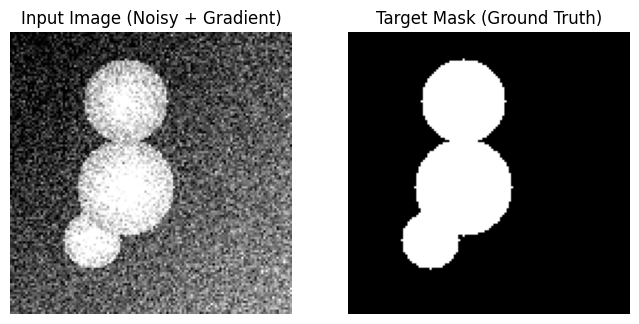

In [ ]:
class SyntheticCellDataset(Dataset):
    def __init__(self, num_samples=100, size=128):
        self.num_samples = num_samples
        self.size = size

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        mask = np.zeros((self.size, self.size), dtype=np.float32)
        img = np.zeros((self.size, self.size), dtype=np.float32)

        # Draw 1 to 3 random circular cells
        num_cells = np.random.randint(1, 4)
        for _ in range(num_cells):
            r = np.random.randint(10, 25)
            cx = np.random.randint(r + 10, self.size - r - 10)
            cy = np.random.randint(r + 10, self.size - r - 10)

            cv2.circle(mask, (cx, cy), r, 1.0, -1)

            # Soft cell interior gradient
            for i in range(r, 0, -1):
                intensity = 0.5 + (0.5 * (1.0 - i / r))
                cv2.circle(img, (cx, cy), i, intensity, -1)

        # Background illumination gradient
        x = np.linspace(0, 0.3, self.size)
        y = np.linspace(0, 0.3, self.size)
        xv, yv = np.meshgrid(x, y)
        img = img + (xv + yv).astype(np.float32)

        # Noise
        noise = np.random.normal(0, 0.15, img.shape).astype(np.float32)
        img_noisy = np.clip(img + noise, 0.0, 1.0)

        img_tensor = torch.tensor(img_noisy).unsqueeze(0)
        mask_tensor = torch.tensor(mask).unsqueeze(0)

        return img_tensor, mask_tensor

# Preview dataset item
dataset = SyntheticCellDataset(num_samples=1)
sample_img, sample_mask = dataset[0]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(sample_img.squeeze(), cmap='gray')
axes[0].set_title("Input Image (Noisy + Gradient)")
axes[0].axis('off')

axes[1].imshow(sample_mask.squeeze(), cmap='gray')
axes[1].set_title("Target Mask (Ground Truth)")
axes[1].axis('off')
plt.show()

### Step 4: Train the U-Net Model

We initialize our datasets, define the `BCEWithLogitsLoss`, and optimize using `Adam`. We will train for 20 epochs.

In [ ]:
# Load datasets
train_dataset = SyntheticCellDataset(num_samples=200, size=128)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

test_dataset = SyntheticCellDataset(num_samples=10, size=128)

# Setup model, loss, optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.003)

epochs = 20
loss_history = []

print("Training starting...")
model.train()
for epoch in range(epochs):
    epoch_loss = 0.0
    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, masks)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * images.size(0)

    epoch_loss /= len(train_loader.dataset)
    loss_history.append(epoch_loss)
    print(f"Epoch [{epoch+1}/{epochs}] | Loss: {epoch_loss:.5f}")
print("Training Complete!")

Training starting...
Epoch [1/20] | Loss: 0.43143
Epoch [2/20] | Loss: 0.28454
Epoch [3/20] | Loss: 0.21478
Epoch [4/20] | Loss: 0.16208
Epoch [5/20] | Loss: 0.12706
Epoch [6/20] | Loss: 0.09632
Epoch [7/20] | Loss: 0.07541
Epoch [8/20] | Loss: 0.06129
Epoch [9/20] | Loss: 0.05011
Epoch [10/20] | Loss: 0.04090
Epoch [11/20] | Loss: 0.03491
Epoch [12/20] | Loss: 0.02997
Epoch [13/20] | Loss: 0.02572
Epoch [14/20] | Loss: 0.02246
Epoch [15/20] | Loss: 0.01980
Epoch [16/20] | Loss: 0.01744
Epoch [17/20] | Loss: 0.01623
Epoch [18/20] | Loss: 0.01412
Epoch [19/20] | Loss: 0.01289
Epoch [20/20] | Loss: 0.01134
Training Complete!


### Step 5: Inference and Output Plotting (Synthetic Data)

Let's test the U-Net on unseen synthetic data and plot the results.

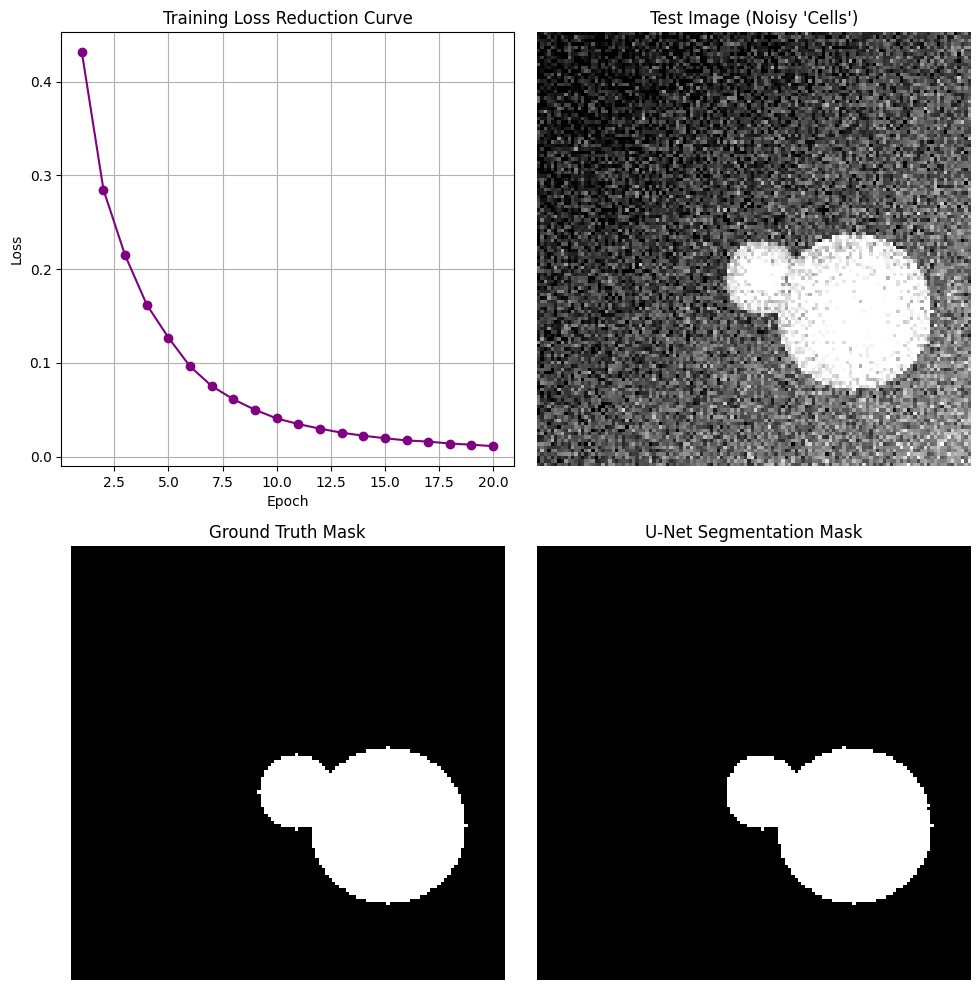

In [ ]:
model.eval()
test_img, test_mask = test_dataset[0]
test_img_batch = test_img.unsqueeze(0).to(device)

with torch.no_grad():
    pred_logits = model(test_img_batch)
    pred_probs = torch.sigmoid(pred_logits).squeeze().cpu().numpy()

# Binarize predictions with a 0.5 threshold
pred_mask = (pred_probs > 0.5).astype(np.float32)

# Plot everything
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# 1. Loss curve
axes[0, 0].plot(range(1, epochs + 1), loss_history, marker='o', color='purple')
axes[0, 0].set_title("Training Loss Reduction Curve")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].grid(True)

# 2. Raw Input
axes[0, 1].imshow(test_img.squeeze().numpy(), cmap='gray')
axes[0, 1].set_title("Test Image (Noisy 'Cells')")
axes[0, 1].axis('off')

# 3. Target ground truth
axes[1, 0].imshow(test_mask.squeeze().numpy(), cmap='gray')
axes[1, 0].set_title("Ground Truth Mask")
axes[1, 0].axis('off')

# 4. U-Net Prediction
axes[1, 1].imshow(pred_mask, cmap='gray')
axes[1, 1].set_title("U-Net Segmentation Mask")
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

## Step 6: Test U-Net with Your Own Uploaded Image!

Here you can upload any image from your computer to test the U-Net model.

> **Note:** Since our U-Net model was trained specifically on circular "cell-like" structures, it will work best on images with high-contrast shapes, circular blobs, or cell-like structures.

Run the cell below, click **"Choose Files"**, and select an image file (`.png`, `.jpg`, `.jpeg`).

Please select an image file to upload:


Saving AgusPop_kecil.jpg to AgusPop_kecil.jpg

Successfully uploaded: AgusPop_kecil.jpg


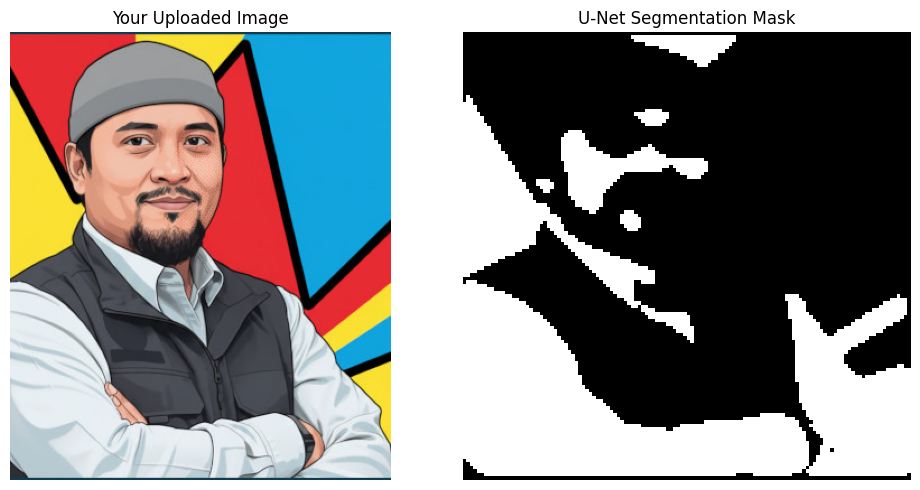

In [ ]:
# This cell handles file uploading and preprocessing specifically for Google Colab
try:
    from google.colab import files
    colab_env = True
except ImportError:
    colab_env = False

if colab_env:
    print("Please select an image file to upload:")
    uploaded = files.upload()

    if len(uploaded) > 0:
        # Get the filename of the uploaded image
        uploaded_filename = list(uploaded.keys())[0]
        print(f"\nSuccessfully uploaded: {uploaded_filename}")

        # 1. Load the image
        img = cv2.imread(uploaded_filename)

        # 2. Preprocess
        # Convert BGR to Grayscale
        gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        # Resize to 128x128 to match model input expected shape
        resized_gray = cv2.resize(gray_img, (128, 128))
        # Normalize pixel values to [0.0, 1.0]
        normalized_img = resized_gray.astype(np.float32) / 255.0

        # Convert to tensor and add channel and batch dimension: [B=1, C=1, H=128, W=128]
        img_tensor = torch.tensor(normalized_img).unsqueeze(0).unsqueeze(0).to(device)

        # 3. Model Inference
        model.eval()
        with torch.no_grad():
            pred_logits = model(img_tensor)
            # Apply sigmoid to convert logit output to probabilities
            pred_probs = torch.sigmoid(pred_logits).squeeze().cpu().numpy()

        # Binarize output (probability > 0.5 means foreground shape)
        predicted_mask = (pred_probs > 0.5).astype(np.float32)

        # 4. Display input and predicted mask side-by-side
        plt.figure(figsize=(10, 5))

        # Plot original uploaded image (Convert BGR to RGB)
        plt.subplot(1, 2, 1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title("Your Uploaded Image")
        plt.axis("off")

        # Plot predicted binary segmentation mask
        plt.subplot(1, 2, 2)
        plt.imshow(predicted_mask, cmap='gray')
        plt.title("U-Net Segmentation Mask")
        plt.axis("off")

        plt.tight_layout()
        plt.show()
    else:
        print("No file was uploaded.")
else:
    print("This cell is configured for Google Colab and cannot run locally without Google Colab APIs.")
    print("To test locally, copy your image to this folder and edit cv2.imread('your_image.jpg') manually.")